In [1]:
import pandas as pd
import io
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [20]:

import pandas as pd
import io
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Dataset de 100 registros: Edad, Salario, Metodo_Pago, Genero, Educacion, Compra
data = """Edad,Salario,Metodo_Pago,Genero,Educacion,Compra
25,35000,Transferencia,Femenino,Universitaria,No
32,48000,Efectivo,Masculino,Media,No
47,70000,Transferencia,Femenino,Universitaria,Si
50,85000,Transferencia,Masculino,Universitaria,Si
22,20000,Efectivo,Femenino,Media,No
18,15000,Efectivo,Masculino,Media,No
40,62000,Transferencia,Femenino,Universitaria,Si
35,58000,Transferencia,Masculino,Media,Si
28,40000,Efectivo,Femenino,Media,No
43,75000,Transferencia,Masculino,Universitaria,Si
24,30000,Efectivo,Femenino,Media,No
55,95000,Transferencia,Masculino,Universitaria,Si
38,50000,Efectivo,Femenino,Universitaria,No
31,42000,Transferencia,Masculino,Media,No
49,88000,Transferencia,Femenino,Universitaria,Si
20,22000,Efectivo,Masculino,Media,No
36,55000,Transferencia,Femenino,Media,Si
42,72000,Transferencia,Masculino,Universitaria,Si
27,38000,Efectivo,Femenino,Media,No
58,105000,Transferencia,Masculino,Universitaria,Si
21,21000,Efectivo,Femenino,Media,No
45,80000,Transferencia,Masculino,Universitaria,Si
33,46000,Efectivo,Femenino,Media,No
29,41000,Transferencia,Masculino,Universitaria,No
52,92000,Transferencia,Femenino,Universitaria,Si
26,34000,Efectivo,Masculino,Media,No
39,64000,Transferencia,Femenino,Universitaria,Si
41,68000,Transferencia,Masculino,Media,Si
23,28000,Efectivo,Femenino,Media,No
46,82000,Transferencia,Masculino,Universitaria,Si
60,110000,Transferencia,Femenino,Universitaria,Si
19,18000,Efectivo,Femenino,Media,No
34,47000,Transferencia,Masculino,Media,No
48,72000,Transferencia,Femenino,Universitaria,Si
25,32000,Efectivo,Masculino,Media,No
30,45000,Transferencia,Femenino,Media,No
56,98000,Transferencia,Masculino,Universitaria,Si
44,78000,Transferencia,Femenino,Universitaria,Si
29,39000,Efectivo,Masculino,Media,No
37,56000,Transferencia,Femenino,Universitaria,Si
20,19000,Efectivo,Masculino,Media,No
51,89000,Transferencia,Femenino,Universitaria,Si
26,33000,Efectivo,Masculino,Media,No
42,69000,Transferencia,Femenino,Universitaria,Si
31,43000,Efectivo,Masculino,Media,No
57,102000,Transferencia,Femenino,Universitaria,Si
22,23000,Efectivo,Masculino,Media,No
38,54000,Transferencia,Femenino,Media,No
49,91000,Transferencia,Masculino,Universitaria,Si
27,36000,Efectivo,Femenino,Media,No
45,82000,Transferencia,Masculino,Universitaria,Si
33,48000,Transferencia,Femenino,Media,Si
19,16000,Efectivo,Masculino,Media,No
53,94000,Transferencia,Femenino,Universitaria,Si
28,41000,Efectivo,Masculino,Media,No
41,65000,Transferencia,Femenino,Universitaria,Si
32,50000,Efectivo,Masculino,Media,No
59,108000,Transferencia,Femenino,Universitaria,Si
24,29000,Efectivo,Masculino,Media,No
46,84000,Transferencia,Femenino,Universitaria,Si
30,42000,Efectivo,Masculino,Media,No
54,96000,Transferencia,Femenino,Universitaria,Si
21,20000,Efectivo,Masculino,Media,No
43,76000,Transferencia,Femenino,Universitaria,Si
35,60000,Transferencia,Masculino,Media,Si
50,87000,Transferencia,Femenino,Universitaria,Si
23,26000,Efectivo,Masculino,Media,No
39,66000,Transferencia,Femenino,Universitaria,Si
26,35000,Efectivo,Masculino,Media,No
47,74000,Transferencia,Femenino,Universitaria,Si
33,49000,Transferencia,Masculino,Media,No
55,97000,Transferencia,Femenino,Universitaria,Si
22,24000,Efectivo,Masculino,Media,No
44,79000,Transferencia,Femenino,Universitaria,Si
36,58000,Transferencia,Masculino,Media,Si
52,93000,Transferencia,Femenino,Universitaria,Si
20,21000,Efectivo,Masculino,Media,No
41,67000,Transferencia,Femenino,Universitaria,Si
29,40000,Efectivo,Masculino,Media,No
58,106000,Transferencia,Femenino,Universitaria,Si
25,33000,Efectivo,Masculino,Media,No
48,73000,Transferencia,Femenino,Universitaria,Si
34,51000,Transferencia,Masculino,Media,No
56,99000,Transferencia,Femenino,Universitaria,Si
18,17000,Efectivo,Masculino,Media,No
42,71000,Transferencia,Femenino,Universitaria,Si
31,44000,Efectivo,Masculino,Media,No
57,103000,Transferencia,Femenino,Universitaria,Si
24,28000,Efectivo,Masculino,Media,No
49,92000,Transferencia,Femenino,Universitaria,Si
37,57000,Transferencia,Masculino,Media,Si
53,95000,Transferencia,Femenino,Universitaria,Si
23,25000,Efectivo,Masculino,Media,No
40,64000,Transferencia,Femenino,Universitaria,Si
28,42000,Efectivo,Masculino,Media,No
46,85000,Transferencia,Femenino,Universitaria,Si
32,52000,Transferencia,Masculino,Media,No
54,98000,Transferencia,Femenino,Universitaria,Si
21,22000,Efectivo,Masculino,Media,No
45,83000,Transferencia,Femenino,Universitaria,Si"""

df = pd.read_csv(io.StringIO(data.strip()))

In [21]:
# 1. Encoding
df['Metodo_Pago'] = df['Metodo_Pago'].map({'Transferencia': 1, 'Efectivo': 0})
df['Genero'] = df['Genero'].map({'Femenino': 1, 'Masculino': 0})
df['Educacion'] = df['Educacion'].map({'Universitaria': 2, 'Media': 1})
df['Compra'] = df['Compra'].map({'Si': 1, 'No': 0})

# 2. Selección de variables
X = df.drop('Compra', axis=1).values
y = df['Compra'].values

# 3. División 70/30 (Ahora el test tiene 30 registros, mucho más sólido)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 4. Escalado
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 5. Entrenamiento
logistic_classifier = LogisticRegression()
logistic_classifier.fit(X_train, y_train)

# 6. Predicciones y Métricas
y_pred = logistic_classifier.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred))

Accuracy Score: 100.00%

Matriz de Confusión:
 [[17  0]
 [ 0 13]]

Informe de Clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [22]:
nuevo = sc.transform([[26, 34000, 1, 1, 1]])
print("¿Predicción de Compra?:", "Si" if logistic_classifier.predict(nuevo)[0] == 1 else "No")
print(f"Confianza: {logistic_classifier.predict_proba(nuevo)[0][1]*100:.2f}%")

¿Predicción de Compra?: No
Confianza: 18.01%


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Edad         100 non-null    int64
 1   Salario      100 non-null    int64
 2   Metodo_Pago  100 non-null    int64
 3   Genero       100 non-null    int64
 4   Educacion    100 non-null    int64
 5   Compra       100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


In [25]:
# 7. EVALUAR EL MODELO
print("--- EVALUACIÓN DEL MODELO ---")
print(f"Precisión General: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

--- EVALUACIÓN DEL MODELO ---
Precisión General: 100.00%

Matriz de Confusión:
[[17  0]
 [ 0 13]]


In [26]:
# 8. PROBAR CON NUEVOS DATOS
# Ejemplo: Persona de 35 años, gana 55000, usa Transferencia (1)
nuevo_cliente = sc.transform([[35, 55000, 1 , 2 ,1]])
prediccion = logistic_classifier.predict(nuevo_cliente)
probabilidad = logistic_classifier.predict_proba(nuevo_cliente)

In [27]:
resultado = "Comprará" if prediccion[0] == 1 else "No comprará"
print(f"\n--- PRUEBA NUEVO CLIENTE ---")
print(f"Predicción: {resultado}")
print(f"Probabilidad de Compra: {probabilidad[0][1]*100:.2f}%")


--- PRUEBA NUEVO CLIENTE ---
Predicción: Comprará
Probabilidad de Compra: 76.08%


/tmp/ipykernel_7052/936945322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Compra', y='Salario', data=df, palette='viridis')
/tmp/ipykernel_7052/936945322.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Compra', y='Edad', data=df, palette='plasma')


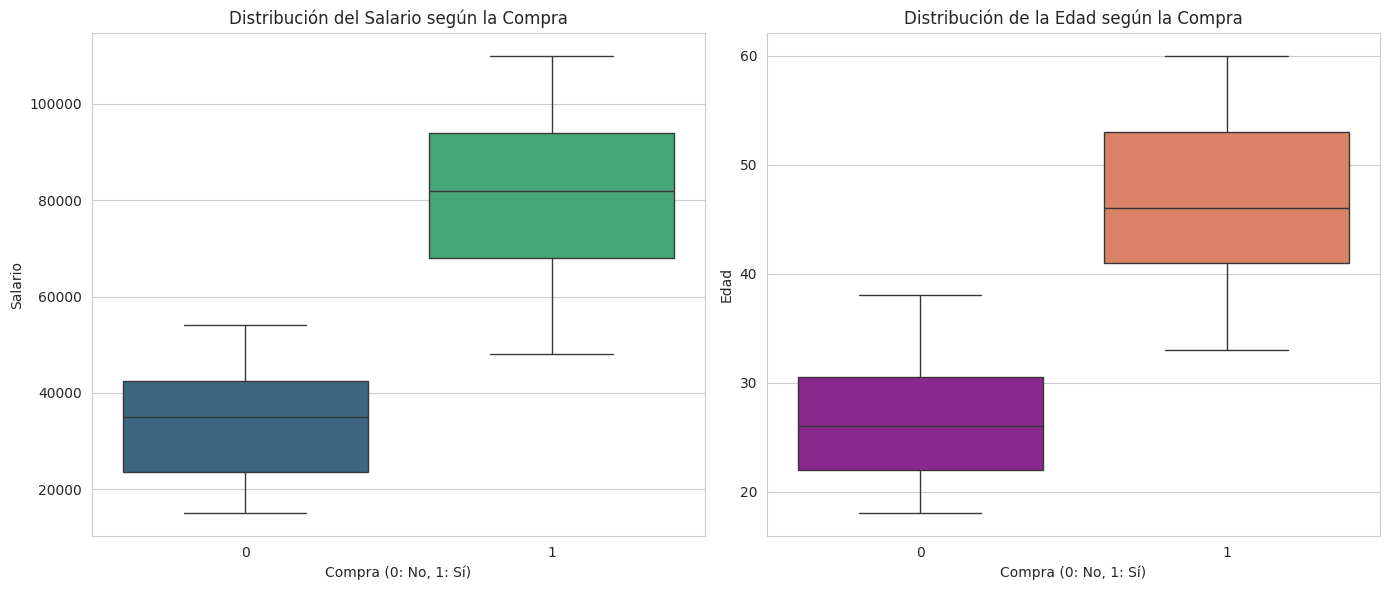

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos para una apariencia profesional
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# Subplot 1: Boxplot de Salario vs Compra
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.boxplot(x='Compra', y='Salario', data=df, palette='viridis')
plt.title('Distribución del Salario según la Compra')
plt.xlabel('Compra (0: No, 1: Sí)')
plt.ylabel('Salario')

# Subplot 2: Boxplot de Edad vs Compra
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(x='Compra', y='Edad', data=df, palette='plasma')
plt.title('Distribución de la Edad según la Compra')
plt.xlabel('Compra (0: No, 1: Sí)')
plt.ylabel('Edad')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

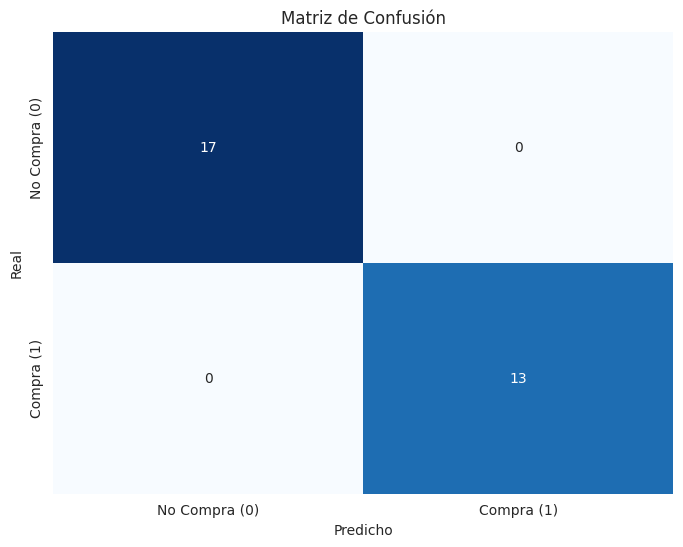

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Compra (0)', 'Compra (1)'], yticklabels=['No Compra (0)', 'Compra (1)'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

/tmp/ipykernel_7052/2559756327.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Característica', y='Coeficiente', data=coef_df, palette='viridis')


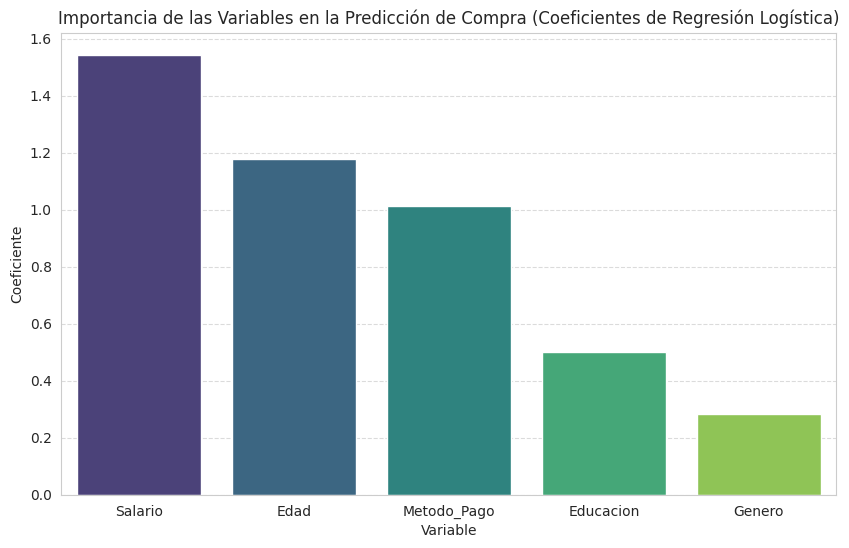

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obtener los coeficientes del modelo
coefficients = logistic_classifier.coef_[0]

# Nombres de las características (ordenadas según la creación de X)
# Se corrigió la lista para incluir todas las variables usadas en X
feature_names = ['Edad', 'Salario', 'Metodo_Pago', 'Genero', 'Educacion']

# Crear un DataFrame para facilitar la visualización
coef_df = pd.DataFrame({'Característica': feature_names, 'Coeficiente': coefficients})

# Ordenar los coeficientes para una mejor visualización (opcional)
coef_df = coef_df.sort_values(by='Coeficiente', ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Característica', y='Coeficiente', data=coef_df, palette='viridis')
plt.title('Importancia de las Variables en la Predicción de Compra (Coeficientes de Regresión Logística)')
plt.xlabel('Variable')
plt.ylabel('Coeficiente')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [33]:
# Al final de tu evaluación (el que tiene método de pago)
accuracy_v2 = accuracy_score(y_test, y_pred)
print(f"Precisión Modelo v2: {accuracy_v2}")

Precisión Modelo v2: 1.0


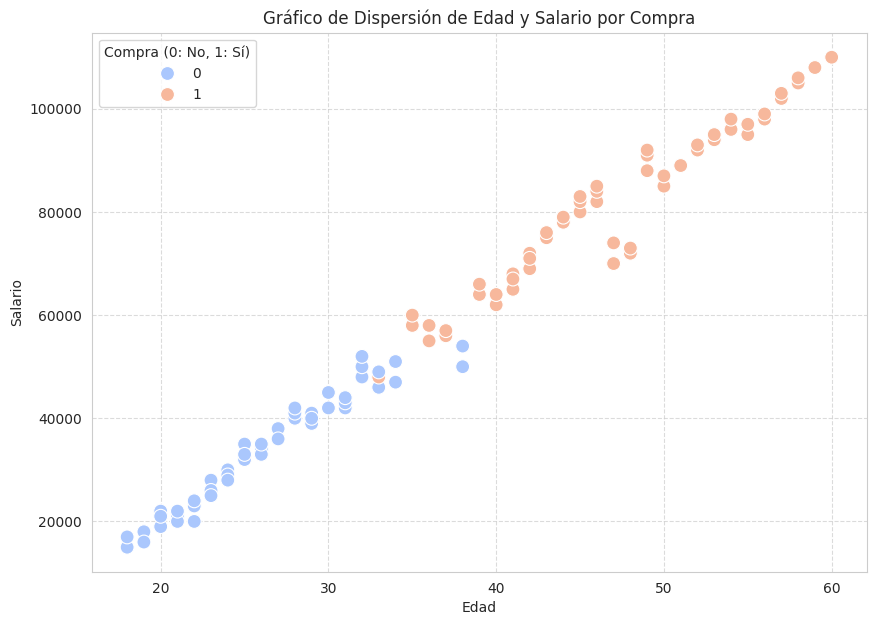

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Gráfico de Dispersión: Edad vs Salario coloreado por Compra
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Edad', y='Salario', hue='Compra', data=df, palette='coolwarm', s=100)
plt.title('Gráfico de Dispersión de Edad y Salario por Compra')
plt.xlabel('Edad')
plt.ylabel('Salario')
plt.legend(title='Compra (0: No, 1: Sí)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


<Figure size 1200x1000 with 0 Axes>

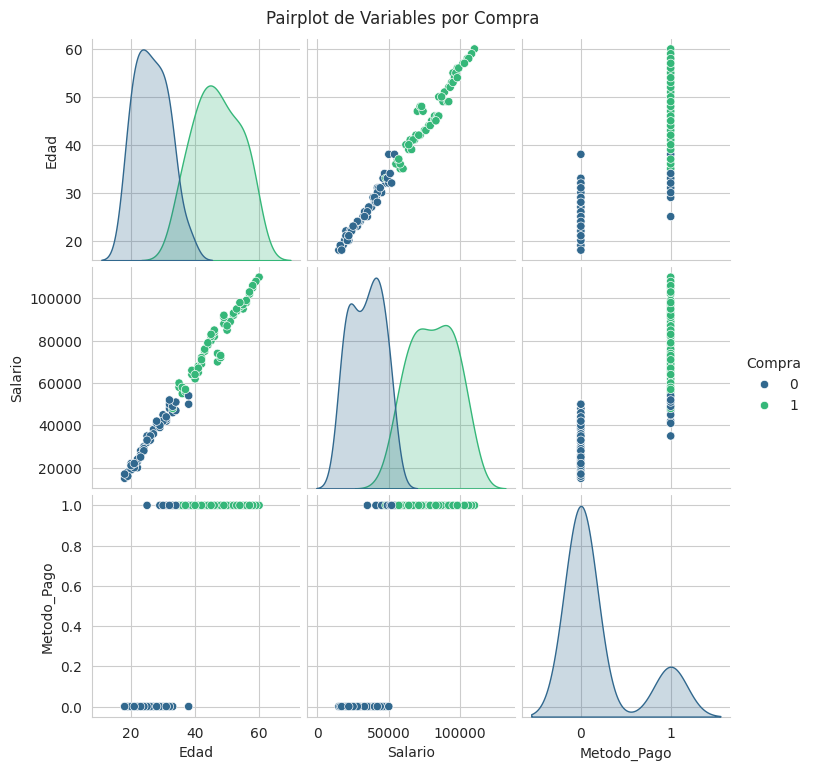

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pairplot de las variables numéricas coloreado por Compra
# Incluimos 'Metodo_Pago' ya que lo hemos convertido a numérico (0, 1)
plt.figure(figsize=(12, 10))
sns.pairplot(df[['Edad', 'Salario', 'Metodo_Pago', 'Compra']], hue='Compra', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot de Variables por Compra', y=1.02) # Ajustar el título para que no se superponga
plt.show()
